# Data Analytics - Frequent Itemset Mining

In [1]:
import csv
import time
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

## Функции программы

In [2]:
def load_dataset_from_csv(filename, delimiter=','):
    """
    Загружает данные из CSV-файла.

    Параметры:
        filename: путь к CSV-файлу;
        delimiter: разделитель в CSV-файле (по умолчанию запятая).

    Возвращает:
        Список транзакций, где каждая транзакция – список объектов.
    """
    dataset = []
    with open(filename, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile, delimiter=delimiter)
        for row in reader:
            # Убираем лишние пробелы и пропускаем пустые строки
            transaction = [item.strip() for item in row if item.strip()]
            if transaction:
                dataset.append(transaction)
    return dataset

def apriori(dataset, min_support, sort_method="support"):
    """
    Поиск частых наборов объектов с помощью алгоритма Apriori.

    Параметры:
        dataset: список транзакций (каждая транзакция – список или множество объектов);
        min_support: порог поддержки; если значение меньше 1, считается относительной поддержкой;
        sort_method: способ упорядочивания результата:
                     "support" - по убыванию поддержки,
                     "lex" - лексикографически.

    Возвращает:
        Список кортежей (itemset, support), где itemset – множество объектов, а support – относительная поддержка.
    """
    total_transactions = len(dataset)
    # Определяем абсолютный порог поддержки:
    absolute_threshold = min_support * total_transactions if min_support < 1 else min_support

    frequent_itemsets = {}
    item_counts = defaultdict(int)

    # Шаг 1: Частотные 1-элементные наборы.
    for transaction in dataset:
        for item in transaction:
            item_counts[item] += 1
    L1 = []
    for item, count in item_counts.items():
        if count >= absolute_threshold:
            itemset = frozenset([item])
            L1.append(itemset)
            frequent_itemsets[itemset] = count / total_transactions

    # Шаг 2: Итеративное построение наборов большей длины.
    current_L = L1
    k = 2
    while current_L:
        candidates = generate_candidates(current_L, k)
        candidate_counts = defaultdict(int)
        for transaction in dataset:
            transaction_set = set(transaction)
            for candidate in candidates:
                if candidate.issubset(transaction_set):
                    candidate_counts[candidate] += 1
        current_L = []
        for candidate, count in candidate_counts.items():
            if count >= absolute_threshold:
                current_L.append(candidate)
                frequent_itemsets[candidate] = count / total_transactions
        k += 1

    # Формируем список результатов в виде (набор, поддержка)
    result = [(set(itemset), support) for itemset, support in frequent_itemsets.items()]

    # Сортировка результата
    if sort_method == "support":
        result = sorted(result, key=lambda x: x[1], reverse=True)
    elif sort_method == "lex":
        result = sorted(result, key=lambda x: tuple(sorted(x[0])))

    return result

def generate_candidates(prev_frequent, k):
    """
    Генерация кандидатов для наборов длины k на основе предыдущего набора частотных (k-1)-элементных наборов.
    """
    candidates = []
    prev_frequent_list = list(prev_frequent)
    len_prev = len(prev_frequent_list)
    for i in range(len_prev):
        for j in range(i + 1, len_prev):
            l1 = sorted(list(prev_frequent_list[i]))
            l2 = sorted(list(prev_frequent_list[j]))
            # Объединяем наборы, если первые k-2 элементов совпадают
            if l1[:k-2] == l2[:k-2]:
                candidate = prev_frequent_list[i] | prev_frequent_list[j]
                if not has_infrequent_subset(candidate, prev_frequent):
                    candidates.append(candidate)
    return candidates

def has_infrequent_subset(candidate, prev_frequent):
    """
    Проверяет, что каждый (k-1)-поднабор кандидата присутствует в наборе частотных (k-1)-элементных наборов.
    """
    candidate_list = list(candidate)
    for subset in combinations(candidate_list, len(candidate) - 1):
        if frozenset(subset) not in prev_frequent:
            return True
    return False

def save_itemsets_to_csv(itemsets, support):
    """
    Сохраняет найденные частые наборы в CSV-файл.

    Параметры:
        itemsets: список кортежей (набор, поддержка)
        support: порог поддержки (в относительных единицах)
        filename_template: шаблон названия файла
    """
    filename = f"Наборы c порогом поддержки {support:.0%}.csv"
    with open(filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file, delimiter=';')
        writer.writerow(["Набор", "Поддержка"])
        for itemset, supp in itemsets:
            writer.writerow([", ".join(itemset), supp])

## Применение алгоритма

In [3]:
# Задаём путь к CSV-файлу с данными (файл baskets.csv должен находиться в рабочей директории)
file_path = "/content/baskets.csv"
dataset = load_dataset_from_csv(file_path, delimiter=',')

# Определяем список пороговых значений поддержки (в относительных величинах)
support_thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]

# Словари для хранения времени выполнения и статистики по наборам для каждого порога
runtimes = {}
itemset_counts = {}  # ключ: порог поддержки, значение: словарь {длина набора: количество}

# Запускаем эксперимент для каждого порогового значения
for support in support_thresholds:
    print(f"Запуск алгоритма Apriori с порогом поддержки {support:.0%}")
    start_time = time.time()
    frequent_itemsets = apriori(dataset, support, sort_method="support")
    elapsed_time = time.time() - start_time
    runtimes[support] = elapsed_time

    # Подсчёт количества частых наборов по их длине
    length_count = {}
    for itemset, supp in frequent_itemsets:
        length = len(itemset)
        length_count[length] = length_count.get(length, 0) + 1
    itemset_counts[support] = length_count

    print(f"  Время выполнения: {elapsed_time:.4f} сек, Найдено наборов: {len(frequent_itemsets)}")

    # Сохранение в CSV
    save_itemsets_to_csv(frequent_itemsets, support)

Запуск алгоритма Apriori с порогом поддержки 1%
  Время выполнения: 1.7226 сек, Найдено наборов: 261
Запуск алгоритма Apriori с порогом поддержки 3%
  Время выполнения: 0.4029 сек, Найдено наборов: 55
Запуск алгоритма Apriori с порогом поддержки 5%
  Время выполнения: 0.1967 сек, Найдено наборов: 28
Запуск алгоритма Apriori с порогом поддержки 10%
  Время выполнения: 0.0269 сек, Найдено наборов: 7
Запуск алгоритма Apriori с порогом поддержки 15%
  Время выполнения: 0.0165 сек, Найдено наборов: 5


## Визуализация

#### Построение графика быстродействия


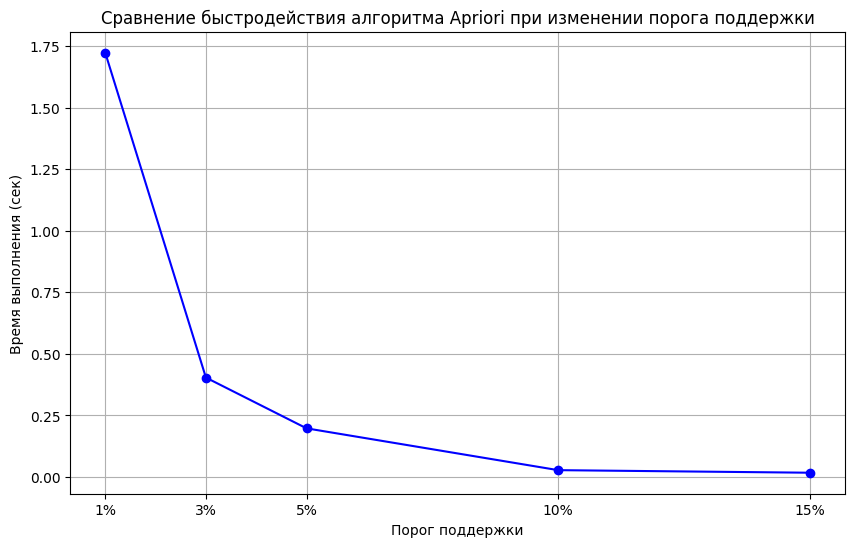

In [4]:
plt.figure(figsize=(10, 6))
x_values = [support for support in support_thresholds]
y_values = [runtimes[support] for support in support_thresholds]
plt.plot(x_values, y_values, marker='o', linestyle='-', color='b')
plt.xlabel('Порог поддержки')
plt.ylabel('Время выполнения (сек)')
plt.title('Сравнение быстродействия алгоритма Apriori при изменении порога поддержки')
plt.grid(True)
plt.xticks(x_values, [f"{s:.0%}" for s in support_thresholds])
plt.savefig('runtime_vs_support.png')
plt.show()

#### Построение графика количества частых наборов по их длине

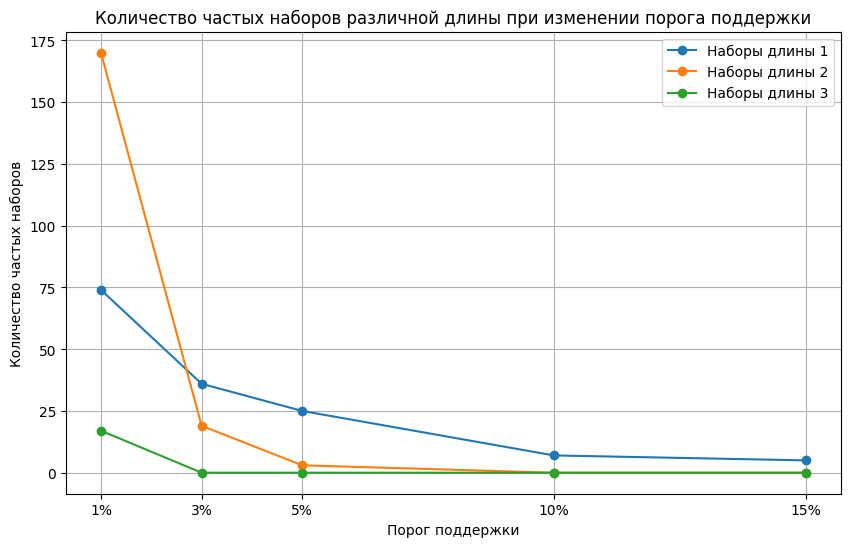

In [5]:
# Собираем все встречающиеся длины наборов
all_lengths = set()
for counts in itemset_counts.values():
    all_lengths.update(counts.keys())
all_lengths = sorted(all_lengths)

plt.figure(figsize=(10, 6))
# Для каждой длины строим график зависимости количества наборов от порога поддержки
for length in all_lengths:
    y_counts = []
    for support in support_thresholds:
        y_counts.append(itemset_counts[support].get(length, 0))
    plt.plot(support_thresholds, y_counts, marker='o', label=f'Наборы длины {length}')

plt.xlabel('Порог поддержки')
plt.ylabel('Количество частых наборов')
plt.title('Количество частых наборов различной длины при изменении порога поддержки')
plt.legend()
plt.grid(True)
plt.xticks(support_thresholds, [f"{s:.0%}" for s in support_thresholds])
plt.savefig('itemset_count_vs_support.png')
plt.show()